Merged price data shape: (980, 5)
        Date     HDFC       ICICI       TCS.NS  RELIANCE.NS
0 2016-07-21  1228.60  229.400146  1143.615967   485.688568
1 2016-07-22  1230.80  230.757797  1147.740967   489.790863
2 2016-07-25  1246.95  235.312500  1173.814209   493.603546
3 2016-07-26  1238.80  229.181152  1170.905884   494.231049
4 2016-07-27  1236.95  237.020554  1182.355591   488.946259

Log returns shape: (979, 5)
        Date      HDFC     ICICI    TCS.NS  RELIANCE.NS
0 2016-07-22  0.001789  0.005901  0.003600     0.008411
1 2016-07-25  0.013036  0.019546  0.022463     0.007754
2 2016-07-26 -0.006557 -0.026402 -0.002481     0.001270
3 2016-07-27 -0.001494  0.033634  0.009731    -0.010751
4 2016-07-28  0.009254  0.005160  0.016041     0.012994

Normal period observations: 246
Crash period observations : 82

================ JARQUE-BERA RESULTS ================

          Period        Stock   JB Statistic       p-value Normal at 5%?
0  Normal Period         HDFC  447680.940767  0.

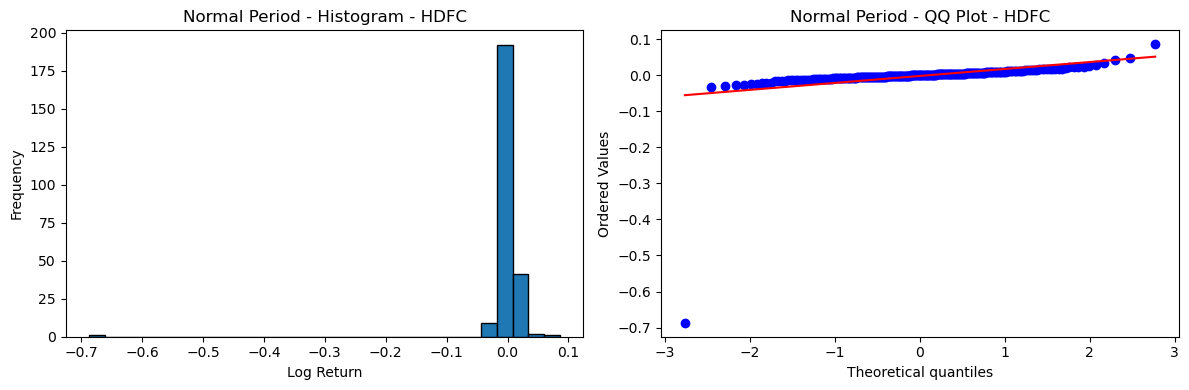

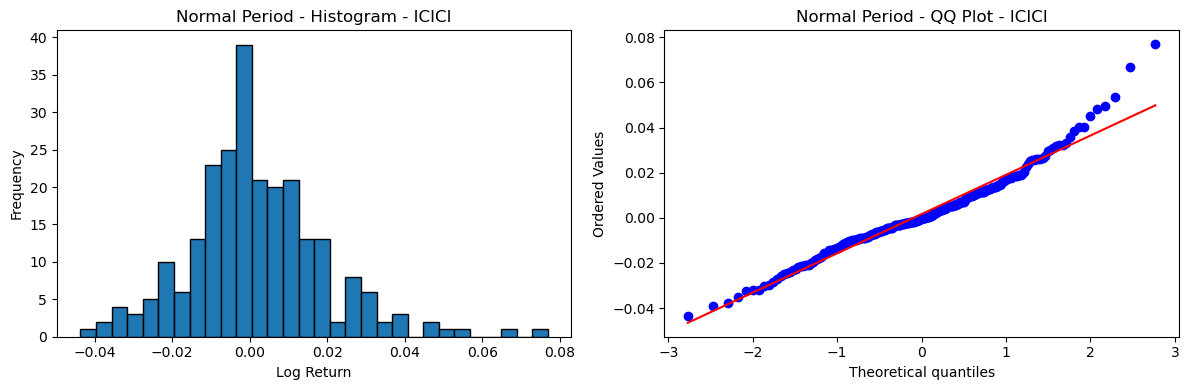

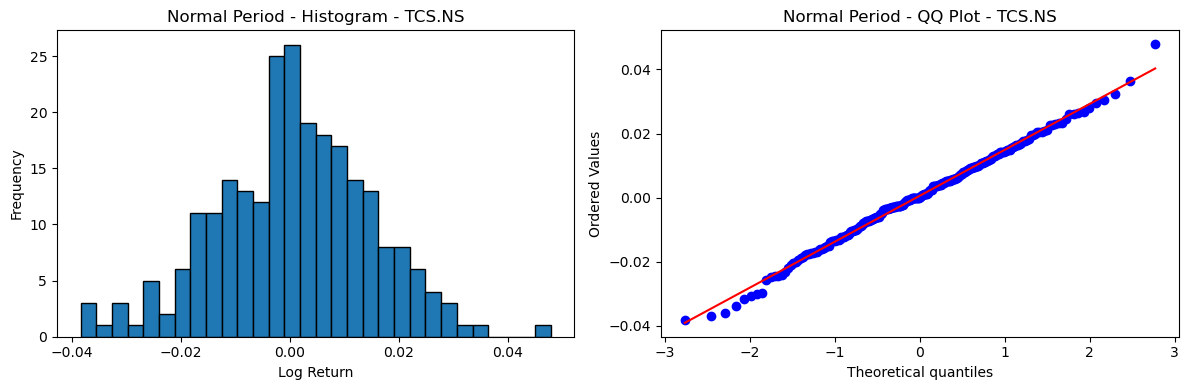

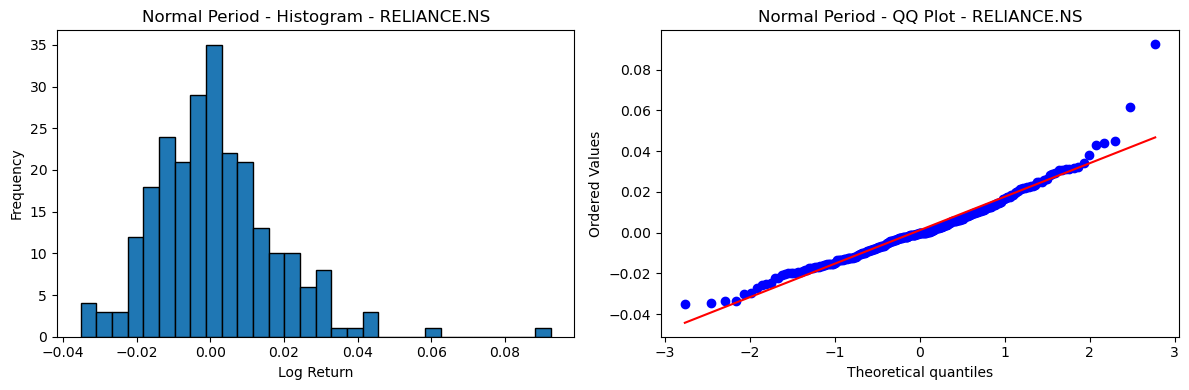

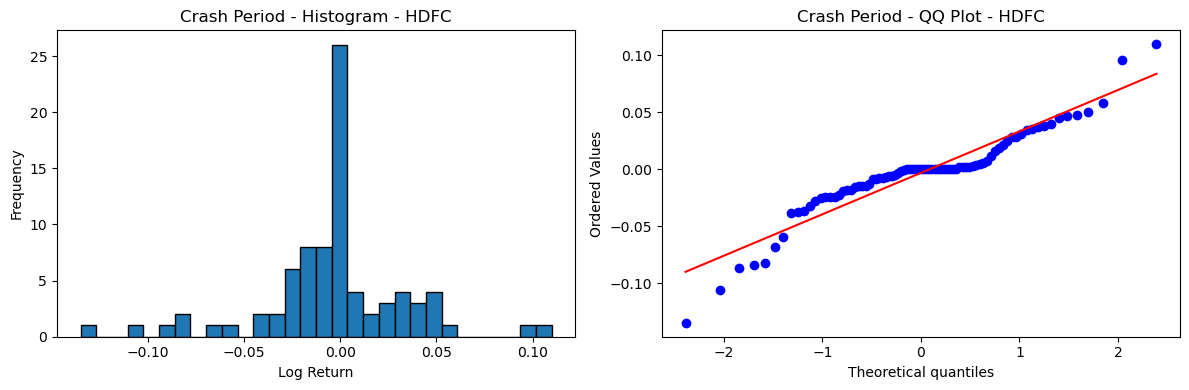

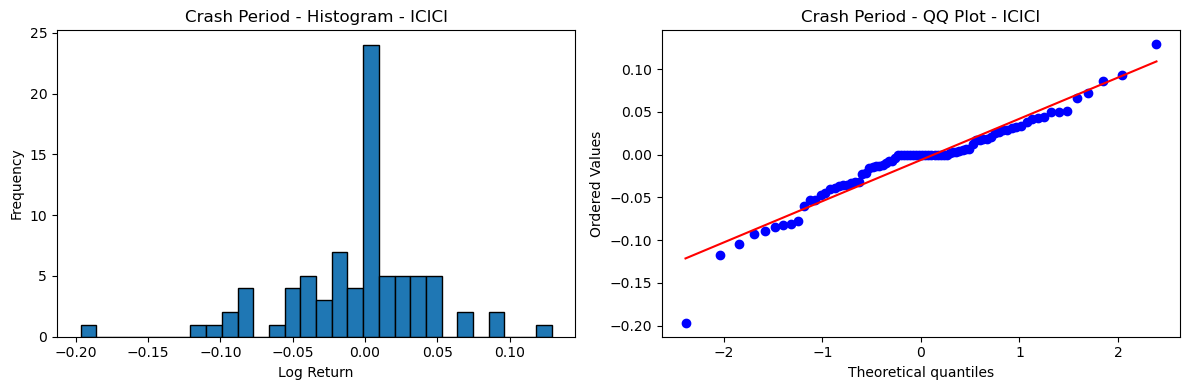

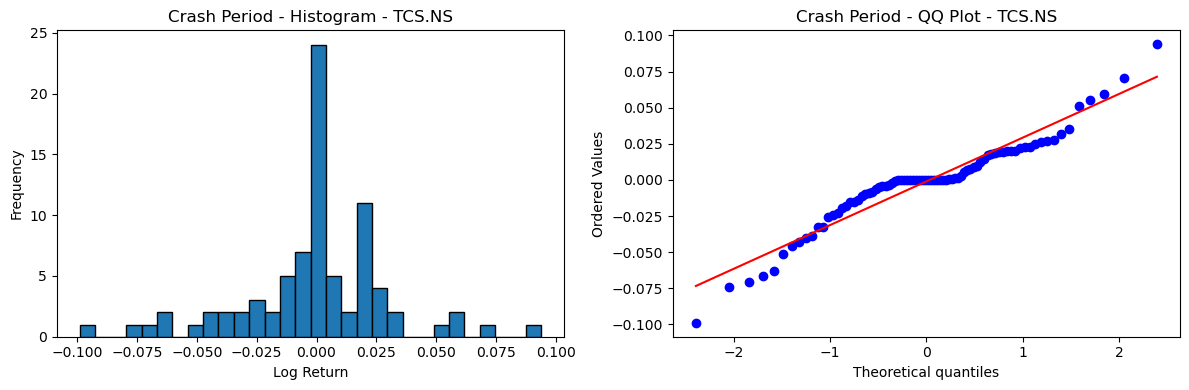

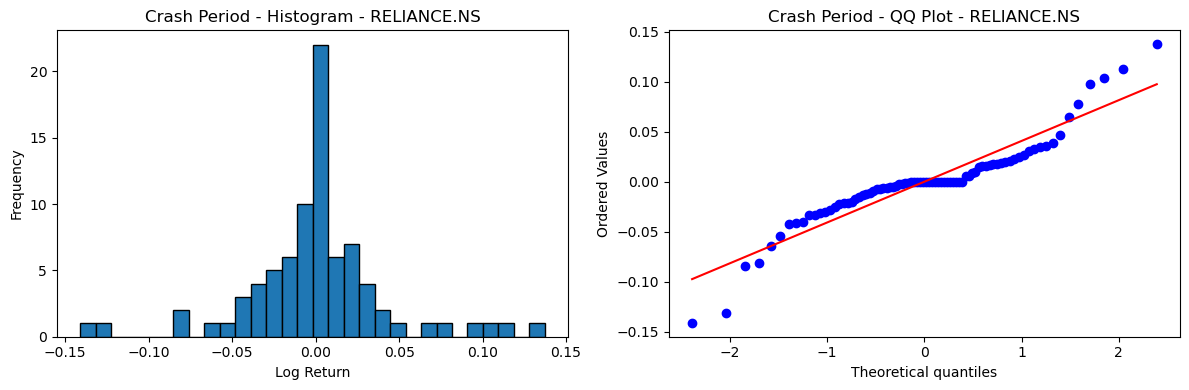

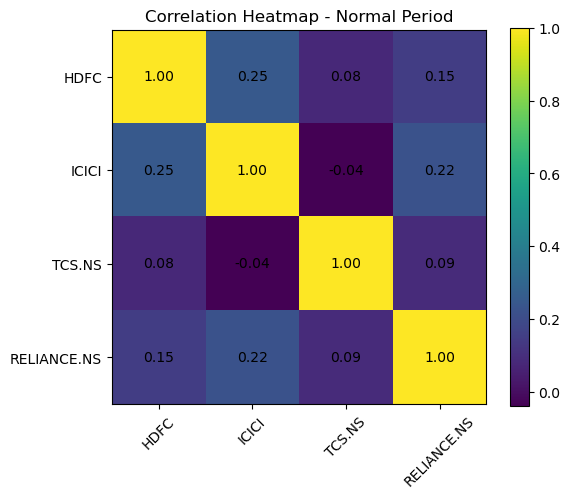

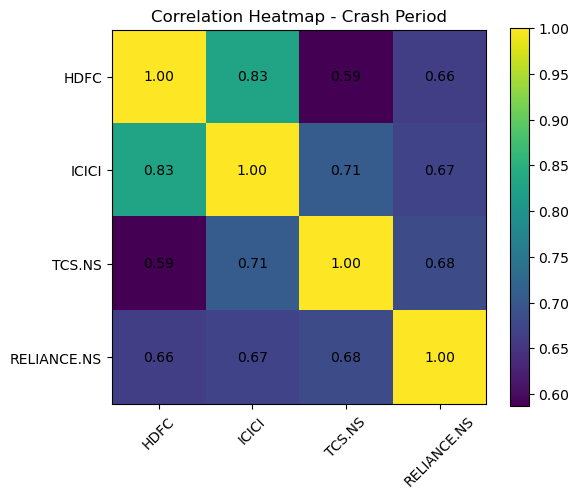

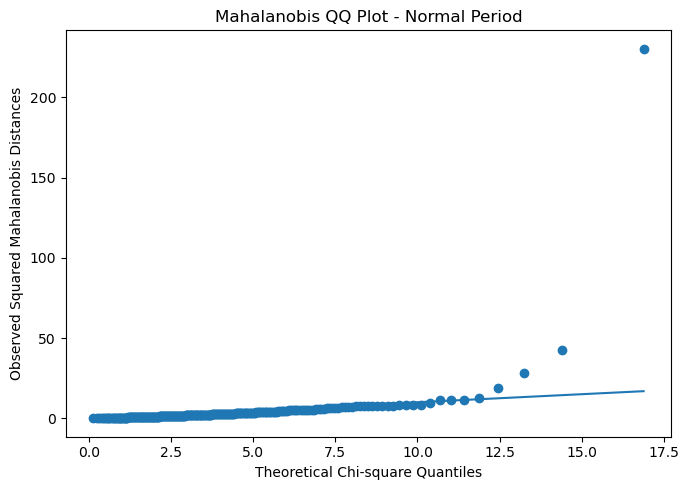

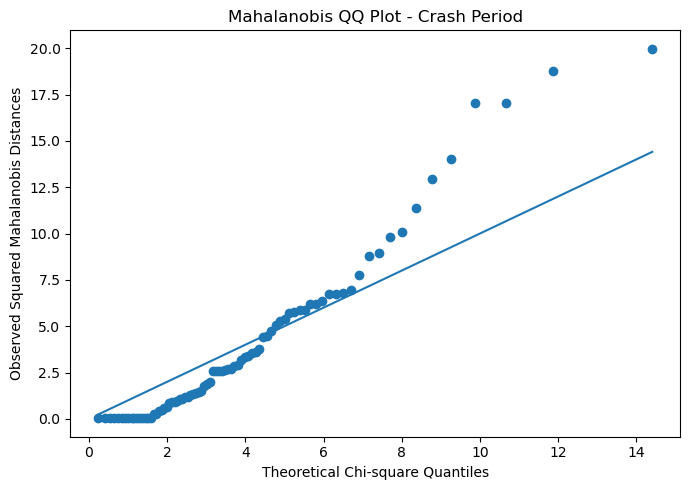


================ FINAL SUMMARY ================

Jarque-Bera summary:
          Period        Stock       p-value Normal at 5%?
0  Normal Period         HDFC  0.000000e+00            No
1  Normal Period        ICICI  5.877696e-13            No
2  Normal Period       TCS.NS  6.938904e-01           Yes
3  Normal Period  RELIANCE.NS  1.711716e-35            No
4   Crash Period         HDFC  2.476424e-06            No
5   Crash Period        ICICI  3.641465e-06            No
6   Crash Period       TCS.NS  3.336418e-03            No
7   Crash Period  RELIANCE.NS  4.084890e-08            No

Mardia summary:
          Period  Skew p-value  Kurtosis p-value Multivariate Normal?
0  Normal Period      0.000000      0.000000e+00                   No
1   Crash Period      0.022987      4.440892e-16                   No


In [3]:
# ============================================================
# NORMAL vs CRASH PERIOD NORMALITY TESTING
# Jarque-Bera + Mardia + Visualizations
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera, probplot, chi2, norm
from scipy.linalg import pinv
from scipy.spatial.distance import mahalanobis

# ------------------------------------------------------------
# 1. FILE PATHS
# ------------------------------------------------------------
files = {
    "HDFC":"C:\\Users\\matra\\Downloads\\HDFCBANK_NSE_1995-2025.csv",
   "ICICI": "C:\\Users\\matra\\Downloads\\ICICIBANK.NS.csv",
   "TCS.NS": "C:\\Users\\matra\\Downloads\\TCS.NS.csv",
    "RELIANCE.NS":"C:\\Users\\matra\\Downloads\\RELIANCE.NS_.csv"
}

# ------------------------------------------------------------
# 2. CHOOSE PERIODS
# ------------------------------------------------------------
# Example:
# Normal period = stable pre-crash period
# Crash period  = COVID crash period
#
# You can change these dates as needed.

normal_start = "2019-01-01"
normal_end   = "2019-12-31"

crash_start  = "2020-02-15"
crash_end    = "2020-05-31"

# ------------------------------------------------------------
# 3. FUNCTION TO LOAD EACH STOCK AND KEEP ONE PRICE COLUMN
# ------------------------------------------------------------
def load_stock_data(file_path, stock_name):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # Convert Date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    # Prefer Adj Close if available, else Close
    if "Adj Close" in df.columns:
        price_col = "Adj Close"
    elif "Close" in df.columns:
        price_col = "Close"
    else:
        raise ValueError(f"No Close/Adj Close column found in {stock_name}")

    out = df[["Date", price_col]].copy()
    out = out.rename(columns={price_col: stock_name})
    return out

# ------------------------------------------------------------
# 4. LOAD AND MERGE ALL STOCKS
# ------------------------------------------------------------
data_list = []

for stock, path in files.items():
    temp = load_stock_data(path, stock)
    data_list.append(temp)

prices = data_list[0]
for temp in data_list[1:]:
    prices = prices.merge(temp, on="Date", how="inner")

prices = prices.sort_values("Date").dropna().reset_index(drop=True)

print("Merged price data shape:", prices.shape)
print(prices.head())

# ------------------------------------------------------------
# 5. COMPUTE LOG RETURNS
# ------------------------------------------------------------
returns = prices.copy()
stock_cols = [col for col in returns.columns if col != "Date"]

returns[stock_cols] = np.log(returns[stock_cols] / returns[stock_cols].shift(1))
returns = returns.dropna().reset_index(drop=True)

print("\nLog returns shape:", returns.shape)
print(returns.head())

# ------------------------------------------------------------
# 6. SPLIT INTO NORMAL PERIOD AND CRASH PERIOD
# ------------------------------------------------------------
normal_data = returns[(returns["Date"] >= normal_start) & (returns["Date"] <= normal_end)].copy()
crash_data  = returns[(returns["Date"] >= crash_start) & (returns["Date"] <= crash_end)].copy()

print("\nNormal period observations:", len(normal_data))
print("Crash period observations :", len(crash_data))

if len(normal_data) < 10:
    print("\nWarning: normal period has too few observations.")
if len(crash_data) < 10:
    print("\nWarning: crash period has too few observations.")

# ------------------------------------------------------------
# 7. JARQUE-BERA TEST
# ------------------------------------------------------------
def jarque_bera_test_table(df, label):
    results = []

    for col in stock_cols:
        series = df[col].dropna()
        stat, p = jarque_bera(series)

        results.append({
            "Period": label,
            "Stock": col,
            "JB Statistic": stat,
            "p-value": p,
            "Normal at 5%?": "Yes" if p > 0.05 else "No"
        })

    return pd.DataFrame(results)

jb_normal = jarque_bera_test_table(normal_data, "Normal Period")
jb_crash  = jarque_bera_test_table(crash_data, "Crash Period")

jb_results = pd.concat([jb_normal, jb_crash], ignore_index=True)

print("\n================ JARQUE-BERA RESULTS ================\n")
print(jb_results)

# ------------------------------------------------------------
# 8. MARDIA TEST IMPLEMENTATION
# ------------------------------------------------------------
# Mardia tests multivariate normality:
# - skewness component
# - kurtosis component
#
# If both p-values are > 0.05, multivariate normality is plausible.
# Otherwise, not supported.

def mardia_test(X):
    """
    X: pandas DataFrame or numpy array with shape (n, p)
    Returns:
        dict with Mardia skewness, kurtosis, stats, p-values
    """
    X = np.asarray(X, dtype=float)
    X = X[~np.isnan(X).any(axis=1)]

    n, p = X.shape

    mean_vec = X.mean(axis=0)
    Xc = X - mean_vec

    S = np.cov(Xc, rowvar=False)
    S_inv = pinv(S)

    # Compute matrix A where A_ij = (x_i - mean)' S_inv (x_j - mean)
    A = Xc @ S_inv @ Xc.T

    # Mardia skewness
    b1p = np.sum(A**3) / (n**2)

    # Mardia kurtosis
    di = np.diag(A)
    b2p = np.sum(di**2) / n

    # Skewness test statistic
    k = p * (p + 1) * (p + 2) / 6
    skew_stat = n * b1p / 6
    skew_p = 1 - chi2.cdf(skew_stat, df=k)

    # Kurtosis test statistic (approximately normal)
    expected_b2p = p * (p + 2)
    var_b2p = (8 * p * (p + 2)) / n
    z_kurt = (b2p - expected_b2p) / np.sqrt(var_b2p)
    kurt_p = 2 * (1 - norm.cdf(abs(z_kurt)))

    return {
        "n": n,
        "p": p,
        "b1p_skewness": b1p,
        "skew_stat": skew_stat,
        "skew_df": k,
        "skew_p_value": skew_p,
        "b2p_kurtosis": b2p,
        "kurt_z": z_kurt,
        "kurt_p_value": kurt_p
    }

mardia_normal = mardia_test(normal_data[stock_cols])
mardia_crash  = mardia_test(crash_data[stock_cols])

print("\n================ MARDIA TEST: NORMAL PERIOD ================\n")
for k, v in mardia_normal.items():
    print(f"{k}: {v}")

print("\n================ MARDIA TEST: CRASH PERIOD ================\n")
for k, v in mardia_crash.items():
    print(f"{k}: {v}")

# ------------------------------------------------------------
# 9. INTERPRETATION FUNCTION
# ------------------------------------------------------------
def interpret_mardia(result, period_name):
    print(f"\nInterpretation for {period_name}")
    print("-" * 50)

    if result["skew_p_value"] > 0.05:
        print("Skewness part: no strong evidence against multivariate normality.")
    else:
        print("Skewness part: rejects multivariate normality.")

    if result["kurt_p_value"] > 0.05:
        print("Kurtosis part: no strong evidence against multivariate normality.")
    else:
        print("Kurtosis part: rejects multivariate normality.")

    if result["skew_p_value"] > 0.05 and result["kurt_p_value"] > 0.05:
        print("Overall: multivariate normality looks plausible.")
    else:
        print("Overall: multivariate normality is NOT supported.")

interpret_mardia(mardia_normal, "Normal Period")
interpret_mardia(mardia_crash, "Crash Period")

# ------------------------------------------------------------
# 10. VISUALIZATION: HISTOGRAMS + QQ PLOTS
# ------------------------------------------------------------
def plot_hist_qq(df, title_prefix):
    for col in stock_cols:
        series = df[col].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Histogram
        axes[0].hist(series, bins=30, edgecolor="black")
        axes[0].set_title(f"{title_prefix} - Histogram - {col}")
        axes[0].set_xlabel("Log Return")
        axes[0].set_ylabel("Frequency")

        # QQ plot
        probplot(series, dist="norm", plot=axes[1])
        axes[1].set_title(f"{title_prefix} - QQ Plot - {col}")

        plt.tight_layout()
        plt.show()

plot_hist_qq(normal_data, "Normal Period")
plot_hist_qq(crash_data, "Crash Period")

# ------------------------------------------------------------
# 11. VISUALIZATION: CORRELATION HEATMAP (MATPLOTLIB ONLY)
# ------------------------------------------------------------
def plot_corr_heatmap(df, title):
    corr = df[stock_cols].corr()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(range(len(stock_cols)))
    ax.set_yticks(range(len(stock_cols)))
    ax.set_xticklabels(stock_cols, rotation=45)
    ax.set_yticklabels(stock_cols)

    for i in range(len(stock_cols)):
        for j in range(len(stock_cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(normal_data, "Correlation Heatmap - Normal Period")
plot_corr_heatmap(crash_data, "Correlation Heatmap - Crash Period")

# ------------------------------------------------------------
# 12. VISUALIZATION: MAHALANOBIS DISTANCE QQ PLOT
# ------------------------------------------------------------
# For multivariate normal data, squared Mahalanobis distances
# should roughly follow Chi-square(df = number of variables)

def plot_mahalanobis_qq(df, title):
    X = df[stock_cols].dropna().values
    n, p = X.shape

    mean_vec = X.mean(axis=0)
    cov_mat = np.cov(X, rowvar=False)
    cov_inv = pinv(cov_mat)

    md_squared = []
    for row in X:
        d = (row - mean_vec).T @ cov_inv @ (row - mean_vec)
        md_squared.append(d)

    md_squared = np.sort(np.array(md_squared))

    # Theoretical chi-square quantiles
    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = chi2.ppf(probs, df=p)

    plt.figure(figsize=(7, 5))
    plt.scatter(theo, md_squared)
    plt.plot([theo.min(), theo.max()], [theo.min(), theo.max()])
    plt.xlabel("Theoretical Chi-square Quantiles")
    plt.ylabel("Observed Squared Mahalanobis Distances")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_mahalanobis_qq(normal_data, "Mahalanobis QQ Plot - Normal Period")
plot_mahalanobis_qq(crash_data, "Mahalanobis QQ Plot - Crash Period")

# ------------------------------------------------------------
# 13. FINAL SUMMARY
# ------------------------------------------------------------
print("\n================ FINAL SUMMARY ================\n")

print("Jarque-Bera summary:")
print(jb_results[["Period", "Stock", "p-value", "Normal at 5%?"]])

print("\nMardia summary:")
summary_df = pd.DataFrame([
    {
        "Period": "Normal Period",
        "Skew p-value": mardia_normal["skew_p_value"],
        "Kurtosis p-value": mardia_normal["kurt_p_value"],
        "Multivariate Normal?": "Yes"
        if (mardia_normal["skew_p_value"] > 0.05 and mardia_normal["kurt_p_value"] > 0.05)
        else "No"
    },
    {
        "Period": "Crash Period",
        "Skew p-value": mardia_crash["skew_p_value"],
        "Kurtosis p-value": mardia_crash["kurt_p_value"],
        "Multivariate Normal?": "Yes"
        if (mardia_crash["skew_p_value"] > 0.05 and mardia_crash["kurt_p_value"] > 0.05)
        else "No"
    }
])

print(summary_df)